# Exploratory Data Analysis (EDA)

This notebook provides a reusable starting point for exploratory data analysis in this project.

**Default dataset:** `../data/clean/EnrollmentsAUS_category_with_numeric_key.csv`

> If you want to explore a different file, update `dataset_path` in the next code cell.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

# Resolve the dataset path robustly after moving the notebook into a subfolder
dataset_name = "EnrollmentsAUS_category_with_numeric_key.csv"
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
dataset_path = None

for root in candidate_roots:
    candidate = root / "data" / "clean" / dataset_name
    if candidate.exists():
        dataset_path = candidate
        break

if dataset_path is None:
    raise FileNotFoundError(f"Dataset not found from working directory: {Path.cwd()}")

try:
    df = pd.read_csv(dataset_path)
except UnicodeDecodeError:
    df = pd.read_csv(dataset_path, encoding="latin-1")

print(f"Loaded {dataset_path.name}")
print(f"Resolved path: {dataset_path}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
df.head()

Loaded EnrollmentsAUS_category_with_numeric_key.csv
Resolved path: c:\Users\neddp\ECC3479-Project-JRGS\data\clean\EnrollmentsAUS_category_with_numeric_key.csv
Rows: 12 | Columns: 11


,Category,2016,2017,2018,2019,2020,2021,2022,2023,2024,CategoryKey
0,Natural & Physical Science,119102,124209,129609,134334,136733,139629,134424,132406,134511,1
1,Information Technology,66355,80090,99986,116623,120916,116296,119278,143253,164464,2
2,Engineering & Related Tech,111060,115231,119909,121980,118229,112931,109812,115197,122954,3
3,Architecture & Building,32074,35604,39459,42370,43478,43773,42327,42174,40942,4
4,Environment & Related,18537,18260,18055,18747,21916,20776,19476,19284,19376,5


## 1. Inspect Data Structure

Review column names, data types, shape, and general dataset information.

In [3]:
print("Column names:")
print(df.columns.tolist())

year_cols = [col for col in df.columns if str(col).isdigit()]
id_cols = [col for col in df.columns if col not in year_cols]

for col in year_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"\nDetected year columns: {year_cols}")
print(f"Identifier columns: {id_cols}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print(f"\nShape: {df.shape}")
print("\nDataset info:")
df.info()

enrollment_long = df.melt(
    id_vars=id_cols,
    value_vars=year_cols,
    var_name="Year",
    value_name="Enrollments",
)
enrollment_long["Year"] = enrollment_long["Year"].astype(int)
enrollment_long["Enrollments"] = pd.to_numeric(enrollment_long["Enrollments"], errors="coerce")

if "Category" in enrollment_long.columns:
    enrollment_long_no_total = enrollment_long[enrollment_long["Category"] != "Total"].copy()
else:
    enrollment_long_no_total = enrollment_long.copy()

print("\nLong-format preview:")
display(enrollment_long.head())

Column names:
['Category', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'CategoryKey']

Detected year columns: ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
Identifier columns: ['Category', 'CategoryKey']

Data types:


,dtype
Category,str
2016,int64
2017,int64
2018,int64
2019,int64
2020,int64
2021,int64
2022,int64
2023,int64
2024,int64



Shape: (12, 11)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Category     12 non-null     str  
 1   2016         12 non-null     int64
 2   2017         12 non-null     int64
 3   2018         12 non-null     int64
 4   2019         12 non-null     int64
 5   2020         12 non-null     int64
 6   2021         12 non-null     int64
 7   2022         12 non-null     int64
 8   2023         12 non-null     int64
 9   2024         12 non-null     int64
 10  CategoryKey  12 non-null     int64
dtypes: int64(10), str(1)
memory usage: 1.2 KB

Long-format preview:


,Category,CategoryKey,Year,Enrollments
0,Natural & Physical Science,1,2016,119102
1,Information Technology,2,2016,66355
2,Engineering & Related Tech,3,2016,111060
3,Architecture & Building,4,2016,32074
4,Environment & Related,5,2016,18537


## 2. Clean Missing Values and Duplicates

Check for null values and duplicate rows, then create a lightly cleaned copy of the dataset.

In [4]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]

print("Missing values by column:")
display(missing_summary.to_frame("missing_count") if not missing_summary.empty else pd.DataFrame({"message": ["No missing values found"]}))

duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

df_clean = df.drop_duplicates().copy()
print(f"Shape after dropping duplicates: {df_clean.shape}")

Missing values by column:


,message
0,No missing values found


Duplicate rows: 0
Shape after dropping duplicates: (12, 11)


## 3. Compute Summary Statistics

Generate descriptive statistics for both numeric and categorical columns.

In [8]:
df_clean_no_total = df_clean[df_clean["Category"] != "Total"].copy() if "Category" in df_clean.columns else df_clean.copy()

numeric_cols = year_cols + (["CategoryKey"] if "CategoryKey" in df_clean.columns else [])
categorical_cols = ["Category"] if "Category" in df_clean.columns else []

print(f"Numeric columns ({len(numeric_cols)}):", numeric_cols)
print(f"Categorical columns ({len(categorical_cols)}):", categorical_cols)

if year_cols:
    print("\nSummary statistics by year:")
    display(df_clean_no_total[year_cols].describe().T)

    year_totals = pd.DataFrame({
        "Total Enrollments": df_clean[year_cols].sum(),
        "Average per Category": df_clean_no_total[year_cols].mean(),
    })
    display(year_totals)
else:
    print("No year columns detected for summary statistics.")

if "Category" in df_clean.columns and year_cols:
    category_change = df_clean_no_total[["Category", year_cols[0], year_cols[-1]]].copy()
    category_change["Absolute Change"] = category_change[year_cols[-1]] - category_change[year_cols[0]]
    category_change["Percent Change"] = (category_change["Absolute Change"] / category_change[year_cols[0]] * 100).round(2)
    display(category_change.sort_values("Absolute Change", ascending=False))

Numeric columns (10): ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'CategoryKey']
Categorical columns (1): ['Category']

Summary statistics by year:


,count,mean,std,min,25%,50%,75%,max
2016,11.0,139313.818182,119680.013640,18537.0,50542.0,111060.0,181655.0,380800.0
2017,11.0,144671.545455,122611.139513,18260.0,57847.0,115231.0,187900.5,389836.0
2018,11.0,149355.363636,123915.084208,18055.0,67827.0,119909.0,192966.5,396813.0
2019,11.0,153740.181818,124954.971645,18747.0,69924.0,121980.0,199960.0,399609.0
2020,11.0,154976.181818,124004.013643,21916.0,70611.5,120916.0,207161.5,380050.0
2021,11.0,153318.272727,122675.016167,20676.0,71150.5,116296.0,215178.0,352882.0
2022,11.0,148402.363636,117871.741851,19476.0,67869.5,119278.0,208491.5,340454.0
2023,11.0,152557.454545,119196.659193,19284.0,67335.0,132406.0,213156.5,360236.0
2024,11.0,159470.272727,121735.158919,19376.0,68542.0,134511.0,229981.0,368989.0


,Total Enrollments,Average per Category
2016,2989661,139313.818182
2017,3104770,144671.545455
2018,3205429,149355.363636
2019,3300940,153740.181818
2020,3327605,154976.181818
2021,3289074,153318.272727
2022,3183837,148402.363636
2023,3278695,152557.454545
2024,3430250,159470.272727


,Category,2016,2024,Absolute Change,Percent Change
1,Information Technology,66355,164464,98109,147.85
5,Health,235033,295498,60465,25.73
6,Education,128277,153177,24900,19.41
8,Society & Culture,312569,329590,17021,5.45
0,Natural & Physical Science,119102,134511,15409,12.94
2,Engineering & Related Tech,111060,122954,11894,10.71
3,Architecture & Building,32074,40942,8868,27.65
9,Creative Arts,93916,96142,2226,2.37
4,Environment & Related,18537,19376,839,4.53
10,Others,34729,28530,-6199,-17.85


## 4. Visualize Enrollment Trends

Plot how enrollments change over time, compare categories, include a Tukey box plot for each area of study, and highlight the latest year.

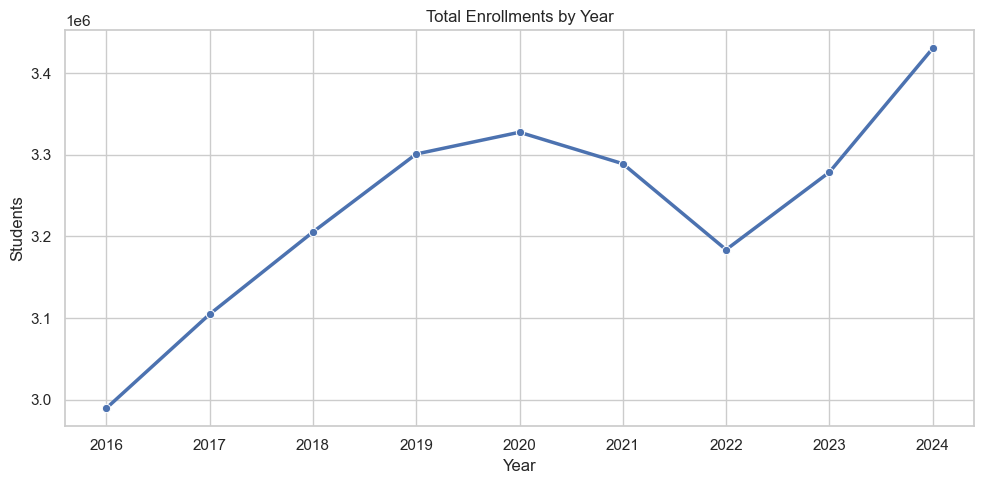

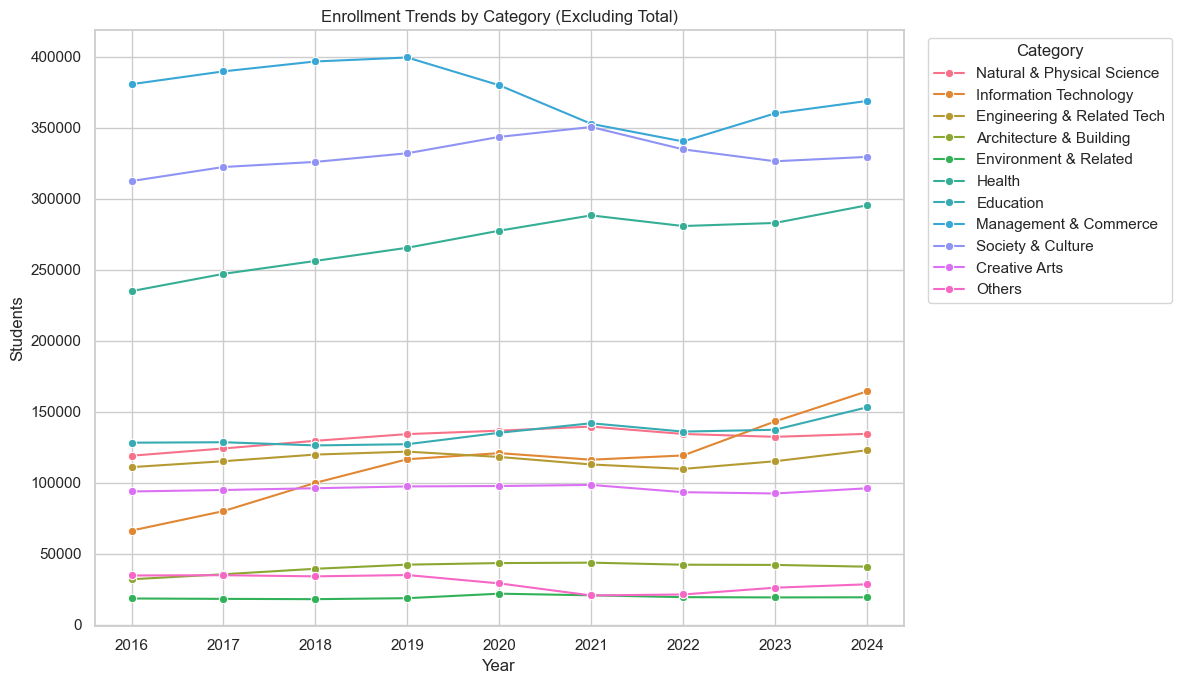

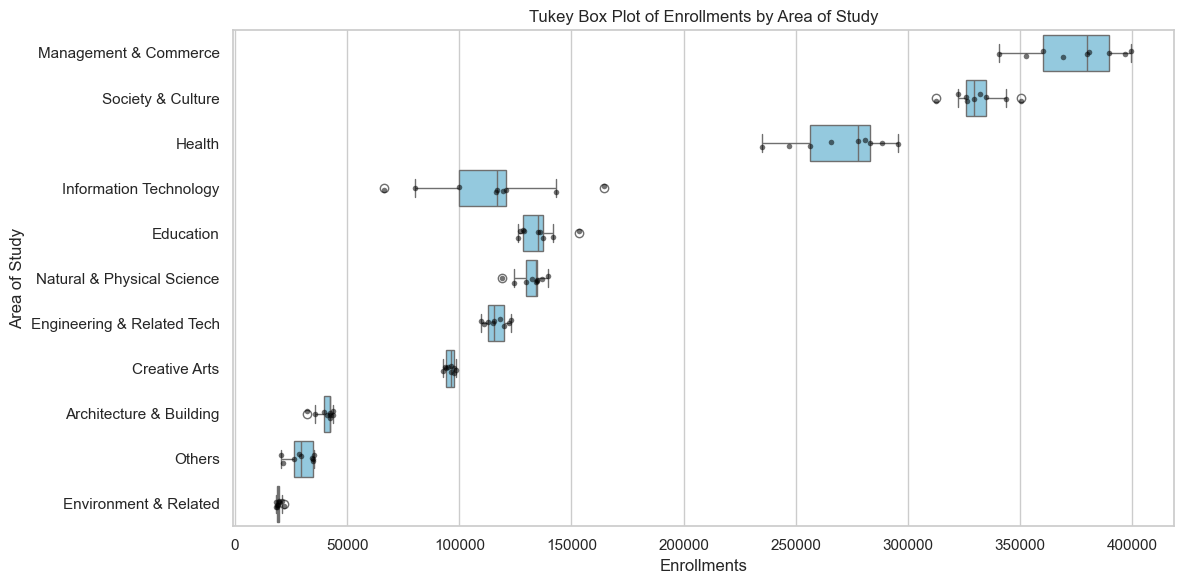

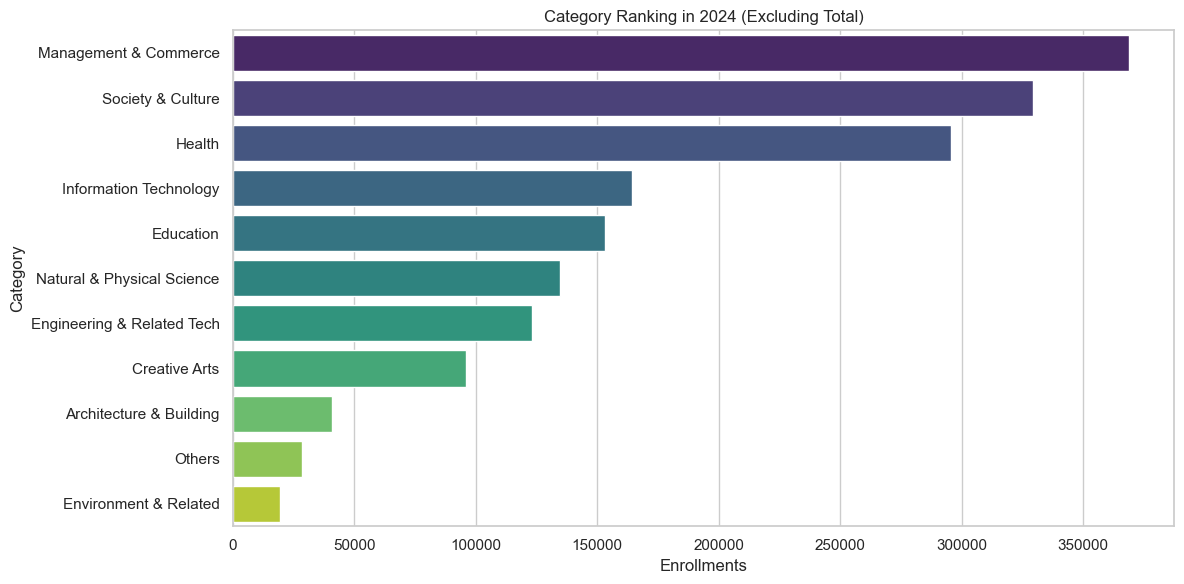

In [10]:
if year_cols:
    yearly_totals = enrollment_long.groupby("Year", as_index=False)["Enrollments"].sum()

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=yearly_totals, x="Year", y="Enrollments", marker="o", linewidth=2.5)
    plt.title("Total Enrollments by Year")
    plt.ylabel("Students")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 7))
    sns.lineplot(data=enrollment_long_no_total, x="Year", y="Enrollments", hue="Category", marker="o")
    plt.title("Enrollment Trends by Category (Excluding Total)")
    plt.ylabel("Students")
    plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    latest_year = max(year_cols, key=int)
    latest_ranking = df_clean_no_total[["Category", latest_year]].sort_values(latest_year, ascending=False)
    category_order = latest_ranking["Category"].tolist()

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=enrollment_long_no_total,
        x="Enrollments",
        y="Category",
        order=category_order,
        whis=1.5,
        color="skyblue",
    )
    sns.stripplot(
        data=enrollment_long_no_total,
        x="Enrollments",
        y="Category",
        order=category_order,
        color="black",
        alpha=0.55,
        size=4,
    )
    plt.title("Tukey Box Plot of Enrollments by Area of Study")
    plt.xlabel("Enrollments")
    plt.ylabel("Area of Study")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.barplot(data=latest_ranking, x=latest_year, y="Category", hue="Category", palette="viridis", legend=False)
    plt.title(f"Category Ranking in {latest_year} (Excluding Total)")
    plt.xlabel("Enrollments")
    plt.tight_layout()
    plt.show()
else:
    print("No year columns detected for trend visualizations.")

## 5. Explore Correlations Across Years

Check how yearly enrollment patterns move together across the time series.

In [ ]:
if len(year_cols) >= 2:
    corr_matrix = df_clean[year_cols].corr()
    display(corr_matrix)

    plt.figure(figsize=(9, 7))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
    plt.title("Correlation Between Enrollment Years")
    plt.tight_layout()
    plt.show()
else:
    print("At least two year columns are needed to compute correlations.")

## 6. Identify Fast-Growing and Unusual Categories

Measure category growth from the first to the last year and flag unusually large changes.

In [ ]:
if "Category" in df_clean.columns and len(year_cols) >= 2:
    growth_df = df_clean_no_total[["Category", year_cols[0], year_cols[-1]]].copy()
    growth_df["Absolute Change"] = growth_df[year_cols[-1]] - growth_df[year_cols[0]]
    growth_df["Percent Change"] = (growth_df["Absolute Change"] / growth_df[year_cols[0]] * 100).round(2)

    q1 = growth_df["Absolute Change"].quantile(0.25)
    q3 = growth_df["Absolute Change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    growth_df["Potential Outlier"] = ~growth_df["Absolute Change"].between(lower, upper, inclusive="both")

    display(growth_df.sort_values("Absolute Change", ascending=False))

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=growth_df.sort_values("Absolute Change", ascending=False),
        x="Absolute Change",
        y="Category",
        hue="Category",
        palette="magma",
        legend=False,
    )
    plt.title(f"Change in Enrollments: {year_cols[0]} to {year_cols[-1]} (Excluding Total)")
    plt.tight_layout()
    plt.show()

    print(f"Outlier bounds for absolute change: lower={lower:.2f}, upper={upper:.2f}")
    display(growth_df[growth_df["Potential Outlier"]])
else:
    print("Category and at least two year columns are required for growth analysis.")

## 7. Separate Tukey Box Plots by Area of Study

This section shows one independent Tukey box plot for each area of study, using only that category's yearly enrollments.

In [ ]:
if "Category" in enrollment_long_no_total.columns:
    categories = enrollment_long_no_total["Category"].dropna().unique().tolist()
    n_cols = 2
    n_rows = (len(categories) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=False)
    axes = np.array(axes).reshape(-1)

    for ax, category in zip(axes, categories):
        cat_values = enrollment_long_no_total.loc[
            enrollment_long_no_total["Category"] == category, "Enrollments"
        ].dropna()

        sns.boxplot(x=cat_values, ax=ax, whis=1.5, color="skyblue")
        sns.stripplot(x=cat_values, ax=ax, color="black", alpha=0.6, size=5)
        ax.set_title(category)
        ax.set_xlabel("Enrollments")
        ax.set_yticks([])

    for ax in axes[len(categories):]:
        ax.set_visible(False)

    plt.suptitle("Independent Tukey Box Plots for Each Area of Study", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Category data is required to create separate Tukey box plots.")

## 7. Additional Statistical Checks

This section tests for correlation, nonlinearity, heterogeneity, and subgroup differences in Australian enrollments.

In [4]:
# Prepare analysis data for additional checks
try:
    from scipy import stats
except ImportError:
    stats = None
    print('scipy is not installed; inferential tests will be skipped.')

analysis_enrollment_df = enrollment_long_no_total.copy()
analysis_enrollment_df = analysis_enrollment_df.dropna(subset=['Year', 'Enrollments'])
analysis_enrollment_df['Year'] = pd.to_numeric(analysis_enrollment_df['Year'], errors='coerce')
analysis_enrollment_df['Enrollments'] = pd.to_numeric(analysis_enrollment_df['Enrollments'], errors='coerce')
analysis_enrollment_df = analysis_enrollment_df.dropna(subset=['Year', 'Enrollments'])

yearly_enrollment = analysis_enrollment_df.groupby('Year', as_index=False)['Enrollments'].sum().sort_values('Year')
category_year_enrollment = analysis_enrollment_df.groupby(['Year', 'Category'], as_index=False)['Enrollments'].sum().sort_values(['Year', 'Category'])

display(category_year_enrollment.head())
print(f'Rows available for checks: {len(category_year_enrollment)}')

,Year,Category,Enrollments
0,2016,Architecture & Building,32074
1,2016,Creative Arts,93916
2,2016,Education,128277
3,2016,Engineering & Related Tech,111060
4,2016,Environment & Related,18537


Rows available for checks: 99


In [5]:
# Correlation checks
pearson_year_enrollment = yearly_enrollment[['Year', 'Enrollments']].corr(method='pearson').iloc[0, 1]
spearman_year_enrollment = yearly_enrollment[['Year', 'Enrollments']].corr(method='spearman').iloc[0, 1]

print(f'Pearson correlation between Year and total Enrollments: {pearson_year_enrollment:.4f}')
print(f'Spearman correlation between Year and total Enrollments: {spearman_year_enrollment:.4f}')

category_corr = (
    category_year_enrollment.groupby('Category')
    .apply(lambda g: g['Year'].corr(g['Enrollments']) if g['Year'].nunique() > 1 else np.nan)
    .reset_index(name='Year_vs_Enrollments_corr')
    .sort_values('Year_vs_Enrollments_corr', ascending=False)
)

print('Category-level correlation between Year and Enrollments')
display(category_corr)

Pearson correlation between Year and total Enrollments: 0.7759
Spearman correlation between Year and total Enrollments: 0.6333
Category-level correlation between Year and Enrollments


,Category,Year_vs_Enrollments_corr
6,Information Technology,0.949774
5,Health,0.949269
2,Education,0.839072
0,Architecture & Building,0.719972
8,Natural & Physical Science,0.718701
10,Society & Culture,0.469865
4,Environment & Related,0.412253
3,Engineering & Related Tech,0.177156
1,Creative Arts,-0.065227
7,Management & Commerce,-0.664642


Linear fit R^2: 0.6020
Quadratic fit R^2: 0.6835
There is evidence of nonlinearity because the quadratic fit improves noticeably.


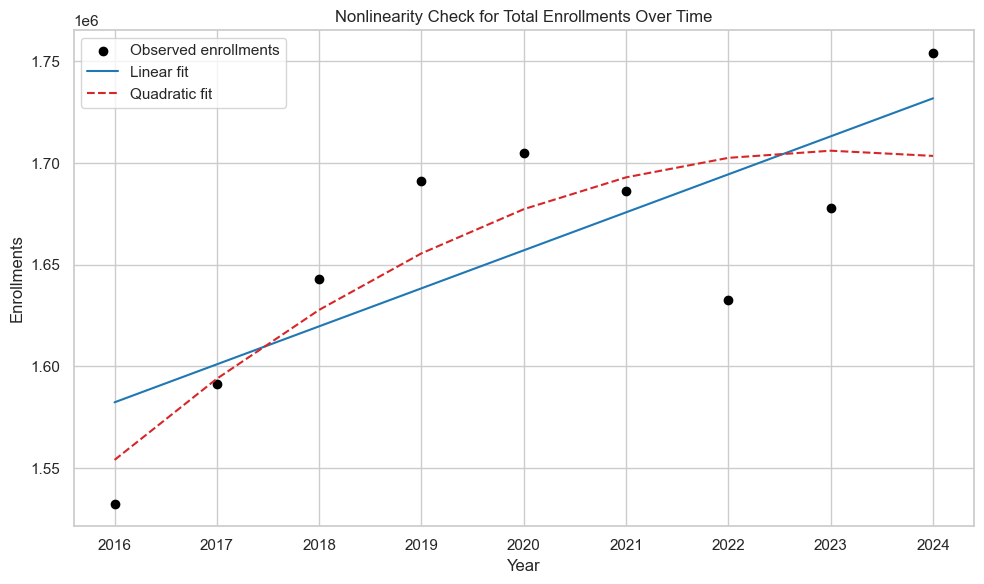

In [6]:
# Nonlinearity check: linear vs quadratic trend in total enrollments
x = yearly_enrollment['Year'].to_numpy(dtype=float)
y = yearly_enrollment['Enrollments'].to_numpy(dtype=float)

lin_coef = np.polyfit(x, y, 1)
quad_coef = np.polyfit(x, y, 2)
lin_pred = np.polyval(lin_coef, x)
quad_pred = np.polyval(quad_coef, x)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

lin_r2 = r2_score(y, lin_pred)
quad_r2 = r2_score(y, quad_pred)

print(f'Linear fit R^2: {lin_r2:.4f}')
print(f'Quadratic fit R^2: {quad_r2:.4f}')
if quad_r2 - lin_r2 > 0.02:
    print('There is evidence of nonlinearity because the quadratic fit improves noticeably.')
else:
    print('The enrollment trend appears mostly linear over time.')

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label='Observed enrollments')
plt.plot(x, lin_pred, color='tab:blue', label='Linear fit')
plt.plot(x, quad_pred, color='tab:red', linestyle='--', label='Quadratic fit')
plt.title('Nonlinearity Check for Total Enrollments Over Time')
plt.xlabel('Year')
plt.ylabel('Enrollments')
plt.legend()
plt.tight_layout()
plt.show()

Variation in enrollments by category


,mean,std,min,max,count,cv
Category,,,,,,
Information Technology,114140.111111,29804.242632,66355,164464,9,0.261120
Management & Commerce,374407.666667,20292.367327,340454,399609,9,0.054199
Health,269951.222222,20260.713060,235033,295498,9,0.075053
Society & Culture,330954.000000,11303.235610,312569,350654,9,0.034153
Education,134924.777778,8714.122672,126360,153177,9,0.064585
Natural & Physical Science,131661.888889,6424.001020,119102,139629,9,0.048792
Others,29411.666667,5761.635336,20676,35058,9,0.195896
Engineering & Related Tech,116367.000000,4697.138916,109812,122954,9,0.040365
Architecture & Building,40244.555556,3950.920592,32074,43773,9,0.098173


Levene's test for equal variances: statistic=4.9022, p-value=1.299e-05
One-way ANOVA across categories: statistic=716.4123, p-value=9.229e-80
Kruskal-Wallis test across categories: statistic=94.0232, p-value=8.501e-16
Variance differs significantly across categories, indicating heterogeneity.
There are statistically significant subgroup differences across categories.


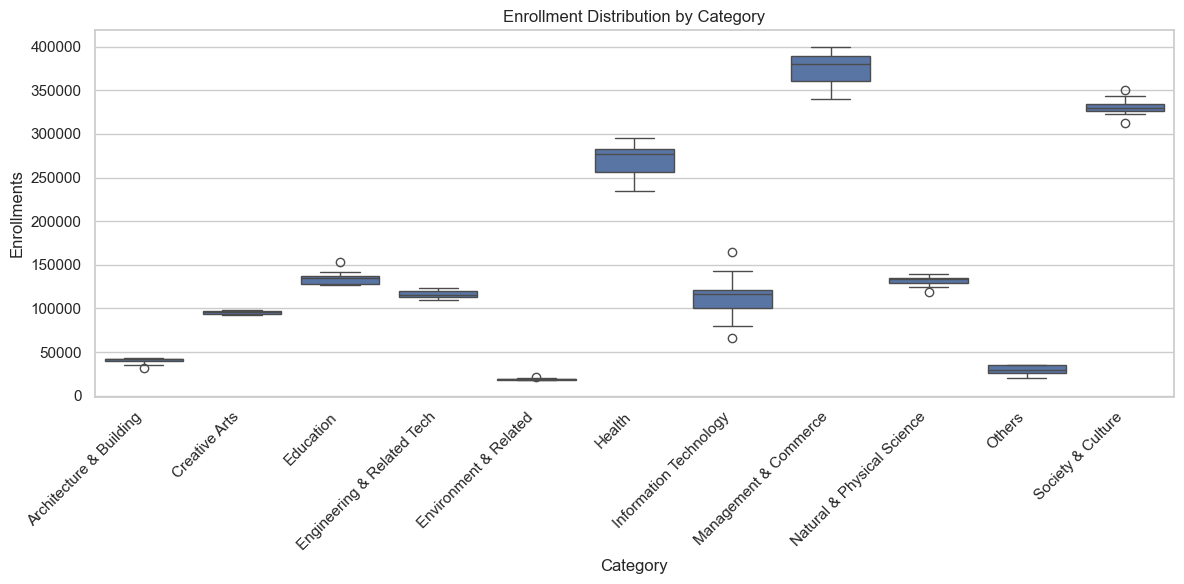

In [7]:
# Heterogeneity and subgroup difference checks
category_stats = (
    category_year_enrollment.groupby('Category')['Enrollments']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .sort_values('std', ascending=False)
)
category_stats['cv'] = category_stats['std'] / category_stats['mean']

print('Variation in enrollments by category')
display(category_stats)

groups = [grp['Enrollments'].values for _, grp in category_year_enrollment.groupby('Category') if len(grp) > 1]

if stats is not None and len(groups) >= 2:
    levene_stat, levene_p = stats.levene(*groups, center='median')
    anova_stat, anova_p = stats.f_oneway(*groups)
    kruskal_stat, kruskal_p = stats.kruskal(*groups)

    print(f"Levene's test for equal variances: statistic={levene_stat:.4f}, p-value={levene_p:.4g}")
    print(f'One-way ANOVA across categories: statistic={anova_stat:.4f}, p-value={anova_p:.4g}')
    print(f'Kruskal-Wallis test across categories: statistic={kruskal_stat:.4f}, p-value={kruskal_p:.4g}')

    if levene_p < 0.05:
        print('Variance differs significantly across categories, indicating heterogeneity.')
    else:
        print('No strong evidence of unequal variance across categories.')

    if anova_p < 0.05 or kruskal_p < 0.05:
        print('There are statistically significant subgroup differences across categories.')
    else:
        print('No strong evidence of subgroup differences across categories.')
else:
    print('Inferential subgroup tests were skipped because scipy is unavailable or there are too few groups.')

plt.figure(figsize=(12, 6))
sns.boxplot(data=category_year_enrollment, x='Category', y='Enrollments')
plt.title('Enrollment Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Enrollments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Structure diagnostics: typical values, spread, skewness, and clumps
structure_df = category_year_enrollment.copy()

summary_stats = structure_df['Enrollments'].describe(percentiles=[0.25, 0.5, 0.75]).to_frame('Enrollments')
q1 = structure_df['Enrollments'].quantile(0.25)
median = structure_df['Enrollments'].median()
q3 = structure_df['Enrollments'].quantile(0.75)
iqr = q3 - q1
mean_val = structure_df['Enrollments'].mean()
std_val = structure_df['Enrollments'].std()
skewness = structure_df['Enrollments'].skew()

print(f'Mean enrollments: {mean_val:,.0f}')
print(f'Median enrollments: {median:,.0f}')
print(f'Standard deviation: {std_val:,.0f}')
print(f'IQR: {iqr:,.0f} (Q1={q1:,.0f}, Q3={q3:,.0f})')
print(f'Skewness: {skewness:.3f}')

category_medians = (
    structure_df.groupby('Category')['Enrollments']
    .median()
    .sort_values(ascending=False)
    .to_frame('MedianEnrollments')
)

structure_df['EnrollmentBand'] = pd.cut(
    structure_df['Enrollments'],
    bins=[0, 50000, 150000, 300000, np.inf],
    labels=['Lower band', 'Middle band', 'Upper band', 'Highest band'],
    include_lowest=True,
)

band_counts = structure_df['EnrollmentBand'].value_counts().sort_index().to_frame('Count')

display(summary_stats)
display(category_medians)
display(band_counts)

plt.figure(figsize=(10, 6))
sns.histplot(structure_df['Enrollments'], bins=12, kde=True, color='steelblue')
plt.title('Distribution of Enrollments Across Category-Year Observations')
plt.xlabel('Enrollments')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Interpretation of Additional Checks

### Key takeaways

- **Structure of the data:** The category-year enrollment values show a **wide spread**, with a mean of about **150,645**, a median of about **119,909**, and a standard deviation of about **116,929**. The interquartile range is about **208,837**, so the middle half of observations is fairly dispersed.
- **Typical values and clumps:** Most observations fall in the **lower-to-middle enrollment range**, while a smaller group of category-year values sits much higher, especially in areas such as **Management & Commerce**, **Society & Culture**, and **Health**. This indicates visible **clumping** rather than one uniform distribution.
- **Skewness:** The distribution is **positively skewed** with skewness around **0.787**, meaning high-enrollment fields pull the upper tail to the right.
- **Trend over time:** Total enrollments show a positive relationship with time, with Pearson correlation around **0.7759** and Spearman correlation around **0.6333**. The quadratic model fits slightly better than the linear one, with $R^2 \approx 0.6835$ compared with $R^2 \approx 0.6020$, suggesting **some nonlinearity** in the growth path.
- **Heterogeneity and subgroup differences:** Levene’s test was significant, with $p \approx 1.299 \times 10^{-5}$, showing that enrollment variability is **not constant across subject areas**. ANOVA and Kruskal-Wallis were also highly significant, with $p \approx 9.229 \times 10^{-80}$ and $p \approx 8.501 \times 10^{-16}$ respectively, confirming **strong subgroup differences**.

### Overall interpretation

Australian university enrollments are not evenly distributed across disciplines. Instead, they cluster around lower and middle ranges with a smaller number of much larger categories, producing a mildly right-skewed structure. The overall trend is upward, but the size and pace of growth differ clearly across subject areas.